# 17 — Matched-aperture total stellar mass (aperture overhaul, 2026-06-10)

Consolidates the photometry/deflector-model/aperture overhaul. Full narrative in `HANDOFF_photometry_aperture_overhaul_2026-06-10.md`. **σ_e is unchanged** (269.62 ± 13.27 km/s); this notebook is the M★ side.

**The arc of fixes** (each prompted by a user catch): 2-comp→single Sérsic · fixed the broken Sérsic fit (`amplitude`=I(r_eff), not the peak) · color-gate(HST)/morph-guard(deep JWST) IR mask growth · WCS cross-corr registration (0.09–0.18″) · matched 2 R_e aperture (fixes the F200LP aperture mismatch) · companion masking.

In [1]:
import numpy as np
from IPython.display import Image, display
import json

## 1. Final masks + matched 2 R_e aperture
Single-Sérsic + color/morph-gated WCS-registered arc (lime) + companion mask (red); matched 2 R_e elliptical aperture (yellow), same physical region all bands.

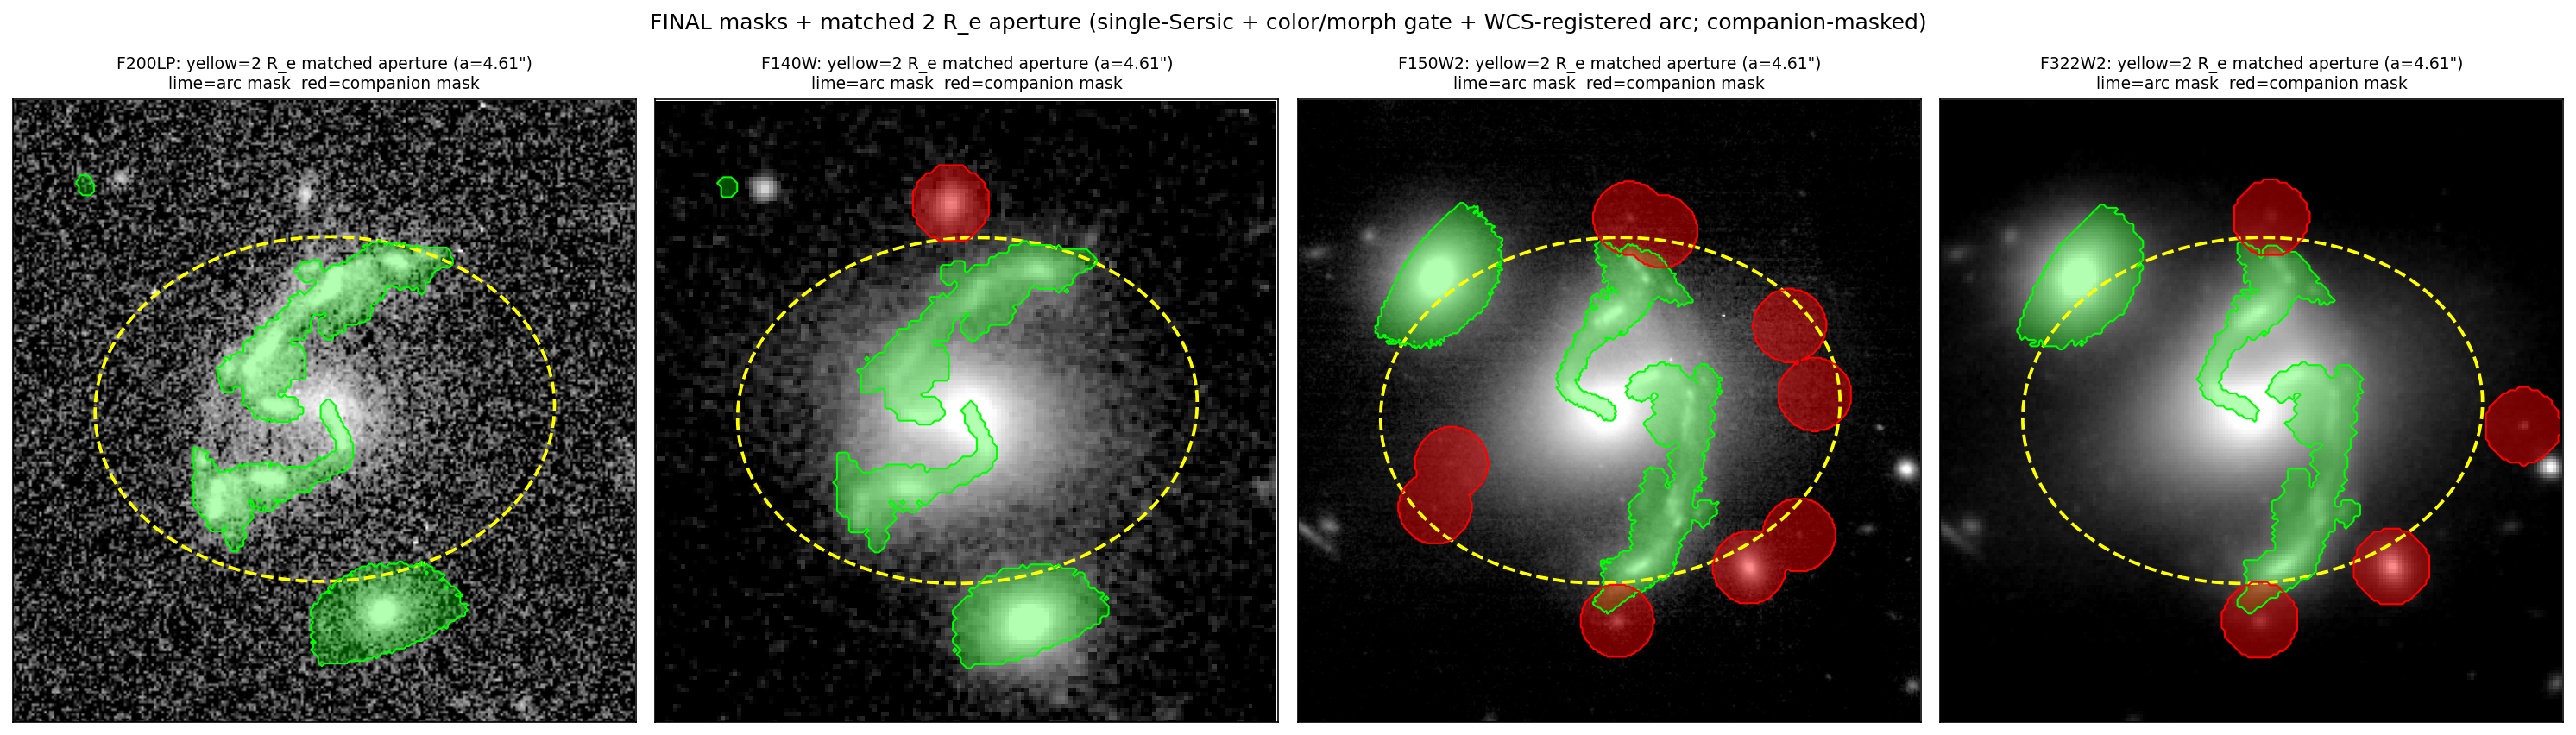

In [2]:
display(Image("../results/figures/final_aperture_masks.png"))

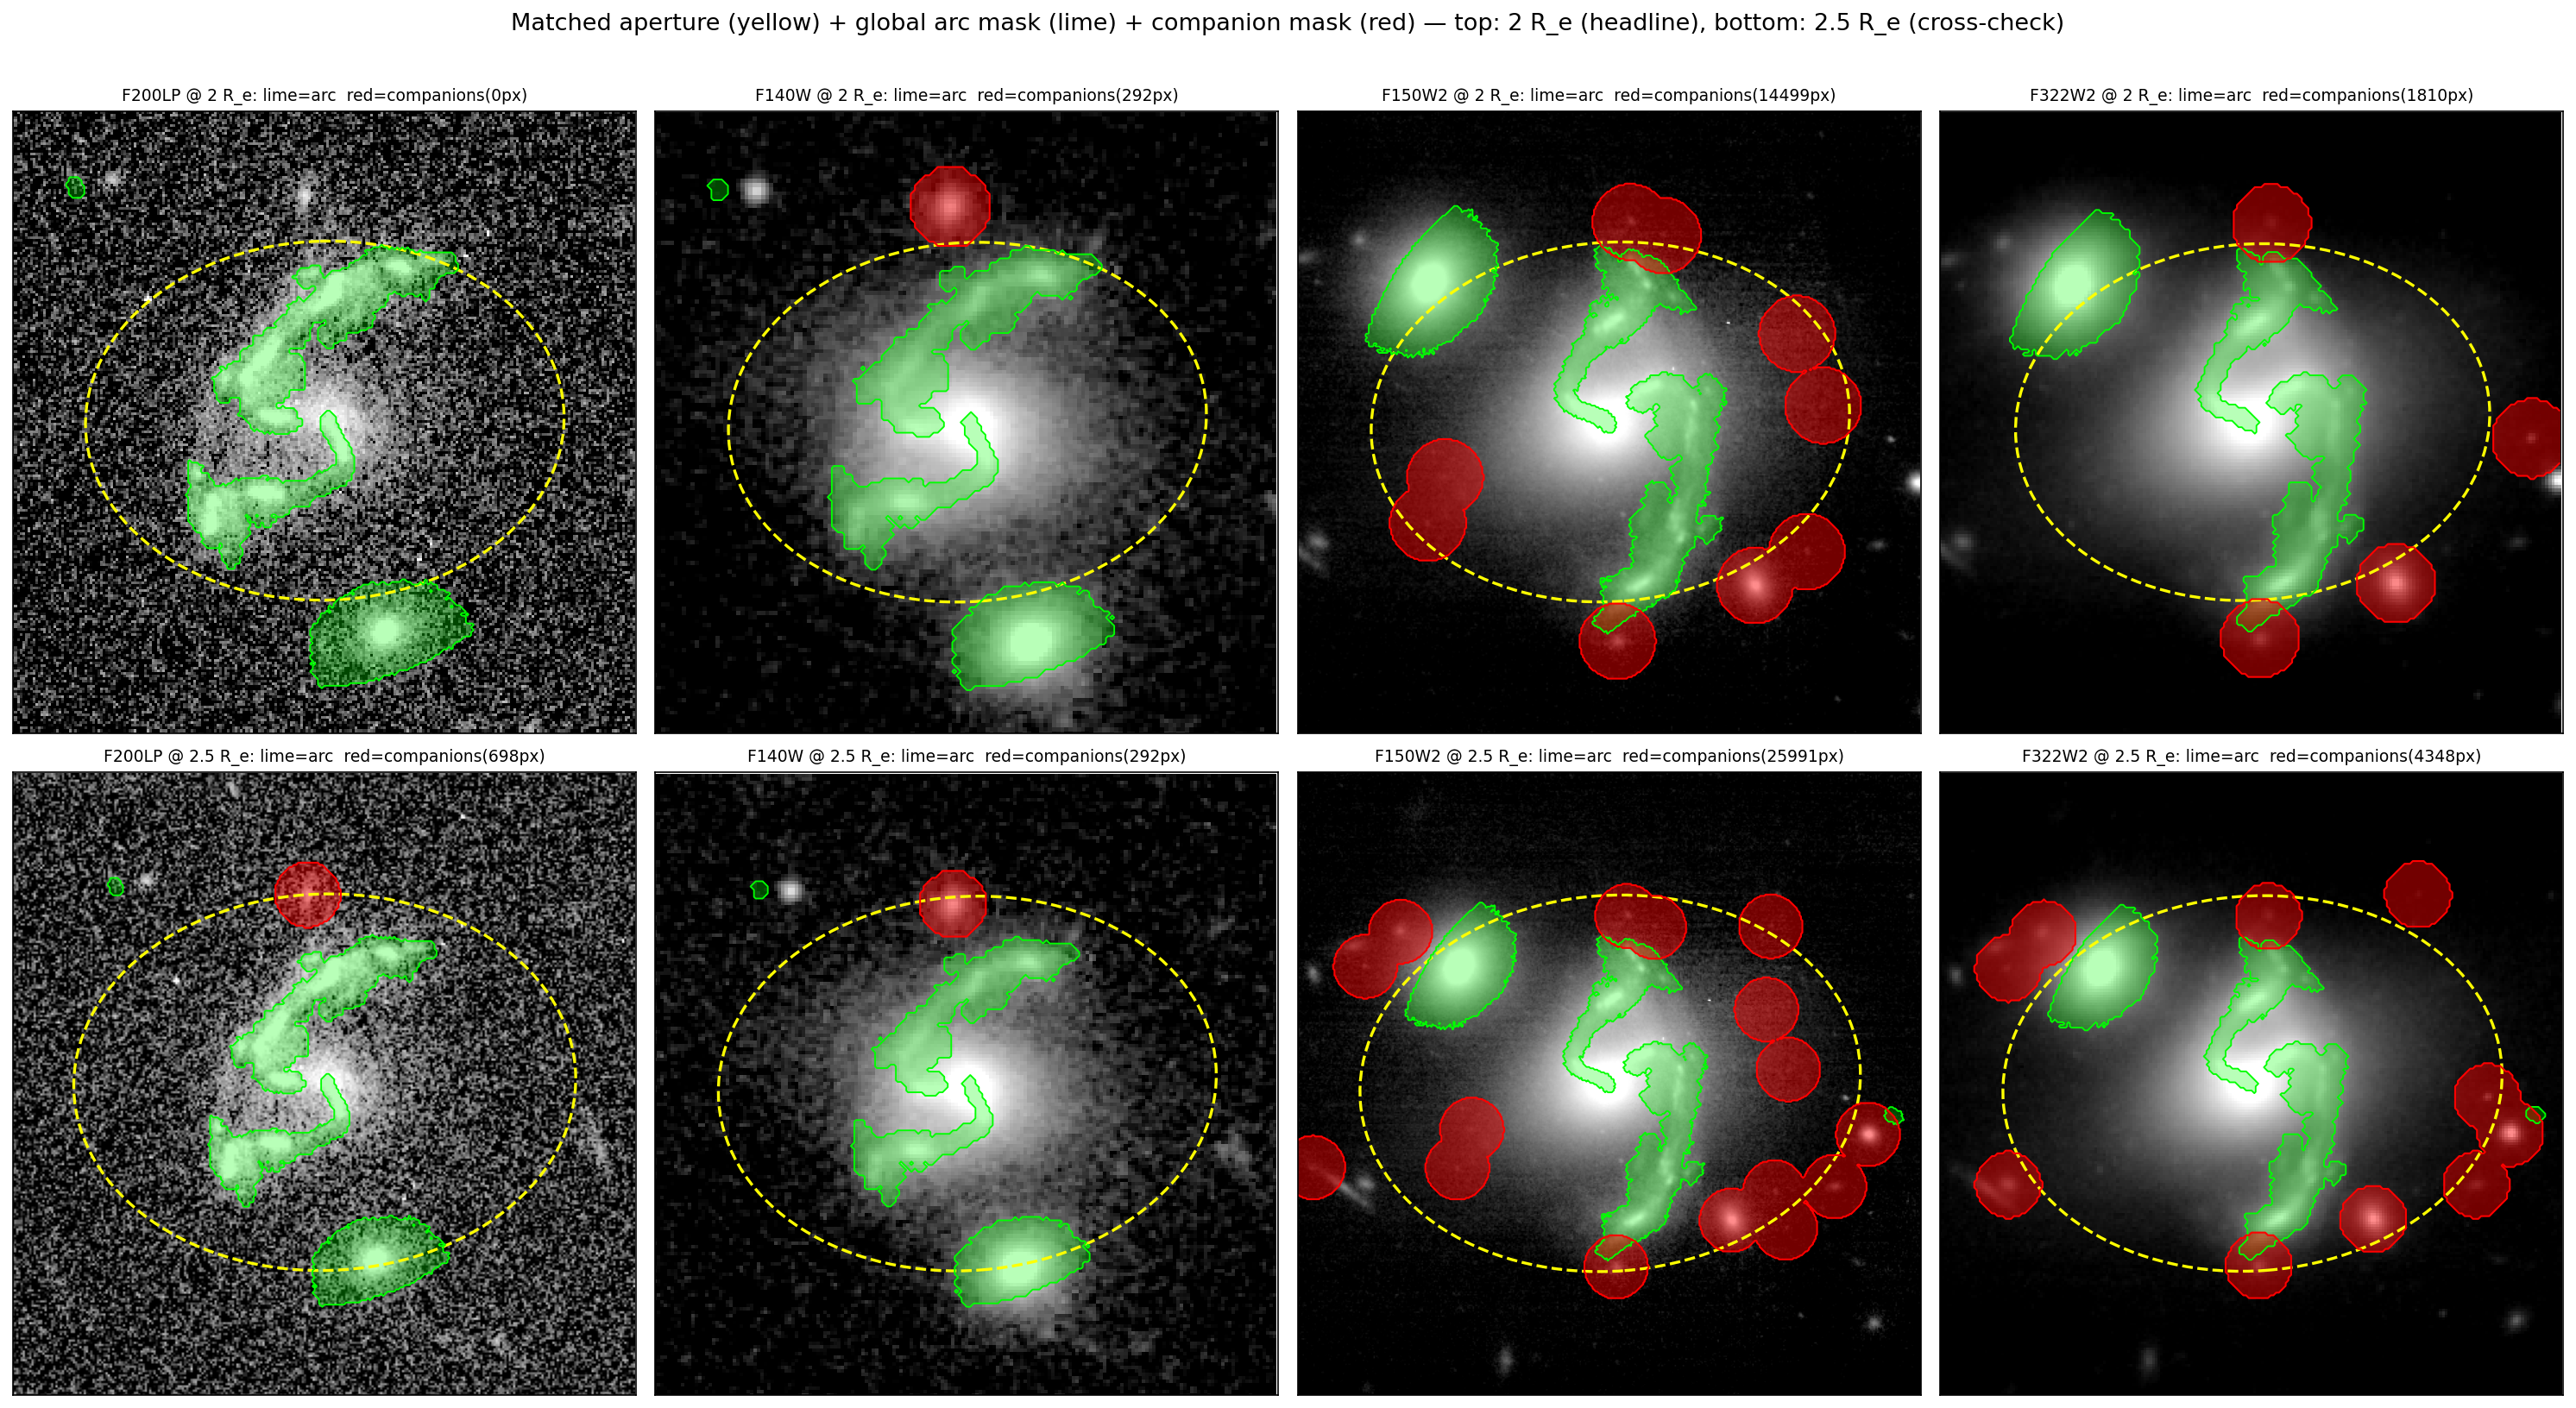

In [3]:
display(Image("../results/figures/aperture_2re_companions.png"))

## 2. Mask evolution (why single-Sérsic + color/morph + registration)
2-comp residual-grown (over-masks red body + companion) → single-Sérsic broken-fit (artifact) → single-Sérsic + color/morph-gated + WCS-registered (final).

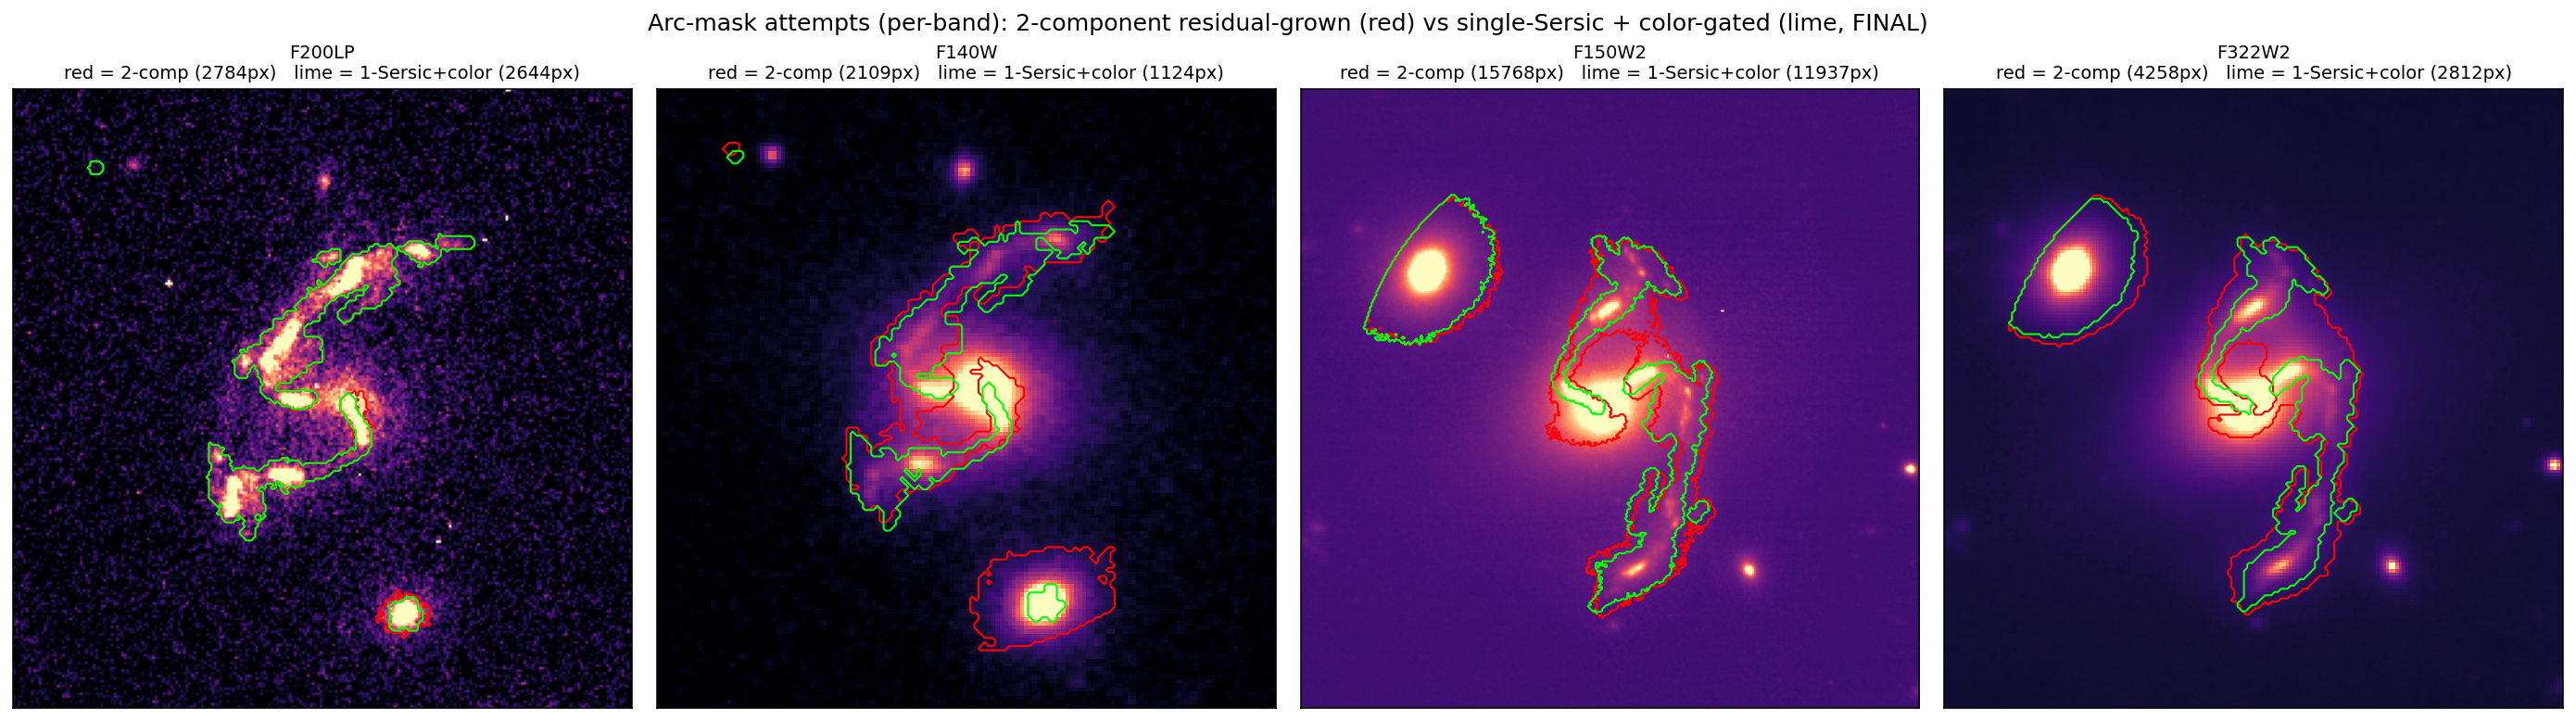

In [4]:
display(Image("../results/figures/mask_attempts_comparison.png"))

## 3. Why the aperture was changed
Old per-band apertures were hand-drawn + **inconsistent**: F200LP a=1.19″ (~0.5 R_e, 17% of light) vs IR a=2.66″ (~1 R_e, ~46%). F200LP under-measured → SED reddened → M★ biased ~+0.14 high. Fix: ONE matched 2 R_e aperture (a=4.61″). 2 R_e over 2.5 R_e: 2.5 triples companions for 0.036 dex less correction. S/N stays high to 2 R_e (>100 all bands).

## 4. Five flux estimators → M★ (empirical → model)
`scripts/aperture_matched_photometry.py`. Headline = **aperture-corrected total** (GAMA/Taylor+2011 `fluxscale`: empirical aperture + Sérsic model wings).

In [5]:
d=np.load("../results/aperture_matched_photometry.npz",allow_pickle=True)
ds=np.load("../results/bagpipes_sersic_refit.npz",allow_pickle=True)
print("log M* (2 R_e, 10% floor):")
for k,lab in [("raw","raw (empirical, lower bound)"),("raw_apcorr","raw+apcorr (most-empirical total)"),("filled","filled (within aperture)"),("total","total (aperture-corrected) — HEADLINE")]:
    p=d[f"logM_{k}_2"]; print(f"  {lab:<42} {p[1]:.3f} (-{p[1]-p[0]:.3f}/+{p[2]-p[1]:.3f})")
print(f"  {'Sersic-total (pure model)':<42} {float(ds['log_M_sersic_p50']):.3f}")
print("\nConvergence of the total across aperture size:")
for nre in [1.0,2.0,2.5]: print(f"  {nre:g} R_e total = {d[f'logM_total_{nre:g}'][1]:.3f}")

log M* (2 R_e, 10% floor):
  raw (empirical, lower bound)               11.220 (-0.132/+0.082)
  raw+apcorr (most-empirical total)          11.354 (-0.143/+0.097)
  filled (within aperture)                   11.361 (-0.127/+0.089)
  total (aperture-corrected) — HEADLINE      11.473 (-0.148/+0.089)
  Sersic-total (pure model)                  11.407

Convergence of the total across aperture size:
  1 R_e total = 11.485
  2 R_e total = 11.473
  2.5 R_e total = 11.453


## 5. Sérsic-only (full-model) systematic budget
`scripts/sersic_total_systematic.py`. The pure-Sérsic-total is model-based → mask-dominated budget.

In [6]:
st=np.load("../results/sersic_total_systematic.npz",allow_pickle=True)
print(f"Sersic-only M* = {float(st['central']):.3f}  ±{float(st['stat']):.3f}(stat) ±{float(st['sys_quad']):.3f}(sys)  [TOTAL ±{float(st['total']):.3f}]")
for k,v in st["components"]: print(f"  {k:<14} ±{float(v):.3f}")

Sersic-only M* = 11.483  ±0.121(stat) ±0.122(sys)  [TOTAL ±0.171]
  mask           ±0.102
  model_form     ±0.057
  flux_floor     ±0.023
  fit_param      ±0.027
  apcorr_recon   ±0.010


## 6. Flux uncertainties — the 10% is a systematic floor, not the measurement error
Propagated statistical errors are **0.03–1.6%**, 6–362× below the 10% floor. The floor accounts for zeropoint/aperture/drizzle-correlated-noise/SED-model systematics.

In [7]:
sp=np.load("../results/sersic_total_photometry.npz",allow_pickle=True)
for i,n in enumerate(list(sp["filter_names"])):
    me=float(sp["mag_aperture_err"][i]); print(f"  {n:<8} mag_err={me:.4f}  -> flux err {100*0.921*me:.2f}%  (10% floor is {0.10/(0.921*me):.0f}x)")

  F200LP   mag_err=0.0172  -> flux err 1.58%  (10% floor is 6x)
  F140W    mag_err=0.0044  -> flux err 0.41%  (10% floor is 25x)
  F150W2   mag_err=0.0005  -> flux err 0.05%  (10% floor is 217x)
  F322W2   mag_err=0.0003  -> flux err 0.03%  (10% floor is 362x)


## 7. Headline + citations
**log M★ = 11.47 +0.09/−0.15** (aperture-corrected total, 2 R_e, 10%). All values via `scripts/paper_values.py` → `results/PAPER_VALUES.json` (single source of truth).

**Method refs:** Taylor et al. 2011 (GAMA `fluxscale` aperture→total for M★) · Sonnenfeld et al. 2013 (SL2S III, lens-deflector Sérsic photometry + mask arc/interlopers) · Graham & Driver 2005 (Sérsic total formalism).

In [8]:
pv=json.load(open("../results/PAPER_VALUES.json"))["logMstar"]
print("PAPER_VALUES.json logMstar:")
for k in ["central_10pct","empirical_raw","raw_apcorr","filled","sersic_total","sersic_total_sys_dex"]:
    print(f"  {k:<22} {pv[k]['value']:.3f}")

PAPER_VALUES.json logMstar:
  central_10pct          11.473
  empirical_raw          11.220
  raw_apcorr             11.354
  filled                 11.361
  sersic_total           11.407
  sersic_total_sys_dex   0.171
